In [1]:
!pip install liac-arff scipy pandas matplotlib seaborn -q

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.io import arff

sns.set_style("whitegrid")
plt.rcParams['font.family'] = 'Arial'

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
# Load data
data, _ = arff.loadarff('dataset.arff')
df = pd.DataFrame(data)

# Convert bytes to string
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].str.decode('utf-8')

# Convert click to integer
df['click'] = df['click'].astype(int)

print(f"Dataset shape: {df.shape}")
print(f"Total records: {df.shape[0]:,}")

Dataset shape: (39948, 12)
Total records: 39,948


In [4]:
print("Column names:")
print(df.columns.tolist())

Column names:
['click', 'impression', 'url_hash', 'ad_id', 'advertiser_id', 'depth', 'position', 'query_id', 'keyword_id', 'title_id', 'description_id', 'user_id']


In [5]:
print("First 5 rows of raw data:")
df.head()

First 5 rows of raw data:


,click,impression,url_hash,ad_id,advertiser_id,depth,position,query_id,keyword_id,title_id,description_id,user_id
0,0,1.0,1.071003e+19,8343295,11700,3.0,3.0,7702266.0,21264,27892,1559,0
1,1,1.0,1.736385e+19,20017077,23798,1.0,1.0,93079.0,35498,4,36476,562934
2,0,1.0,8.915473e+18,21348354,36654,1.0,1.0,10981.0,19975,36105,33292,11621116
3,0,1.0,4.426693e+18,20366086,33280,3.0,3.0,0.0,5942,4057,4390,8778348
4,0,1.0,1.157260e+19,6803526,10790,2.0,1.0,9881978.0,60593,25242,1679,12118311


In [11]:
print("Dataset info:")
print(df.info())

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39948 entries, 0 to 39947
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   click           39948 non-null  int64  
 1   impression      39948 non-null  float64
 2   url_hash        39948 non-null  float64
 3   ad_id           0 non-null      float64
 4   advertiser_id   0 non-null      float64
 5   depth           39948 non-null  float64
 6   position        39948 non-null  float64
 7   query_id        39948 non-null  float64
 8   keyword_id      0 non-null      float64
 9   title_id        0 non-null      float64
 10  description_id  0 non-null      float64
 11  user_id         0 non-null      float64
dtypes: float64(11), int64(1)
memory usage: 3.7 MB
None


In [14]:
print("=" * 50)
print("DESCRIPTIVE STATISTICS")
print("=" * 50)

# Make sure click is numeric
df['click'] = pd.to_numeric(df['click'], errors='coerce')

# Select numerical columns
numerical_cols = ['click', 'impression', 'depth', 'position', 'query_id']
df_numerical = df[numerical_cols]

# Display statistics
print(df_numerical.describe())

DESCRIPTIVE STATISTICS
              click    impression         depth      position      query_id
count  39948.000000  39948.000000  39948.000000  39948.000000  3.994800e+04
mean       0.168419      2.100205      1.960023      1.463853  3.142146e+06
std        0.374243     65.867383      0.715407      0.631545  5.841540e+06
min        0.000000      1.000000      1.000000      1.000000  0.000000e+00
25%        0.000000      1.000000      1.000000      1.000000  2.364250e+03
50%        0.000000      1.000000      2.000000      1.000000  1.128365e+05
75%        0.000000      1.000000      2.000000      2.000000  3.147909e+06
max        1.000000  11820.000000      3.000000      3.000000  2.624010e+07


In [15]:
print("=" * 60)
print("STEP: OVERALL CLICK-THROUGH RATE ANALYSIS")
print("=" * 60)

# Count how many clicks and non-clicks
click_distribution = df['click'].value_counts()
print("Click distribution (0 = no click, 1 = click):")
print(click_distribution)

# Calculate the overall click-through rate
total_impressions = len(df)
total_clicks = df['click'].sum()
overall_click_through_rate = total_clicks / total_impressions * 100

print(f"\nTotal number of ad impressions: {total_impressions:,}")
print(f"Total number of clicks: {total_clicks:,}")
print(f"Overall click-through rate: {overall_click_through_rate:.2f}%")

STEP: OVERALL CLICK-THROUGH RATE ANALYSIS
Click distribution (0 = no click, 1 = click):
click
0    33220
1     6728
Name: count, dtype: int64

Total number of ad impressions: 39,948
Total number of clicks: 6,728
Overall click-through rate: 16.84%


CHART 1: Overall Click-Through Rate Pie Chart
Total ad impressions: 39,948
Total clicks: 6,728
Total non-clicks: 33,220
Overall click-through rate: 16.84%


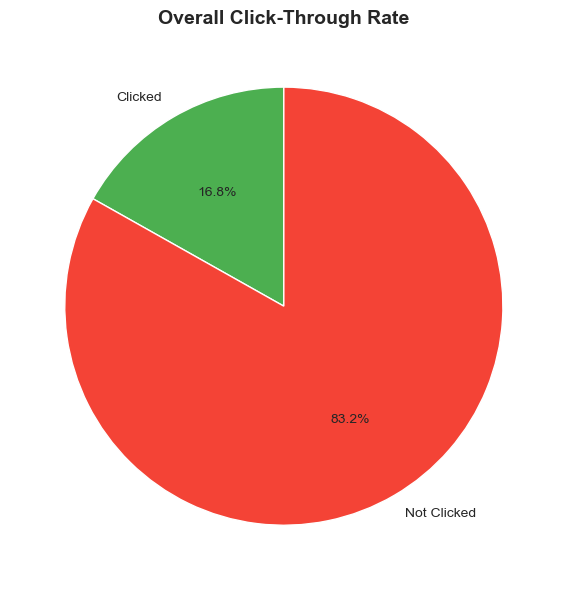

In [16]:
print("=" * 60)
print("CHART 1: Overall Click-Through Rate Pie Chart")
print("=" * 60)

total_impressions = len(df)
total_clicks = df['click'].sum()
total_no_clicks = total_impressions - total_clicks
overall_ctr = total_clicks / total_impressions * 100

print(f"Total ad impressions: {total_impressions:,}")
print(f"Total clicks: {total_clicks:,}")
print(f"Total non-clicks: {total_no_clicks:,}")
print(f"Overall click-through rate: {overall_ctr:.2f}%")

plt.figure(figsize=(8, 6))
plt.pie([total_clicks, total_no_clicks], 
        labels=['Clicked', 'Not Clicked'], 
        autopct='%1.1f%%', 
        colors=['#4CAF50', '#F44336'], 
        startangle=90)
plt.title('Overall Click-Through Rate', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('chart1_overall_ctr.png', dpi=150)
plt.show()

CHART 2: Click-Through Rate by Ad Position
Click-through rate for each ad position:
  Position 1: 20.40%
  Position 2: 12.28%
  Position 3: 6.90%


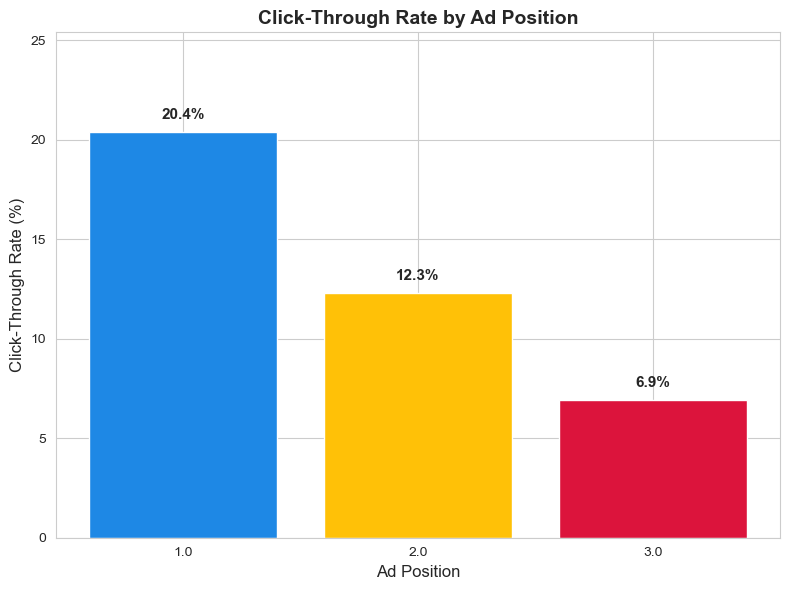


Key finding: Position 1 is 3.0 times higher than Position 3


In [17]:
print("=" * 60)
print("CHART 2: Click-Through Rate by Ad Position")
print("=" * 60)

position_ctr = df.groupby('position')['click'].mean() * 100

print("Click-through rate for each ad position:")
for position, ctr in position_ctr.items():
    print(f"  Position {int(position)}: {ctr:.2f}%")

plt.figure(figsize=(8, 6))
bars = plt.bar(position_ctr.index.astype(str), position_ctr.values, 
               color=['#1E88E5', '#FFC107', '#DC143C'])
plt.xlabel('Ad Position', fontsize=12)
plt.ylabel('Click-Through Rate (%)', fontsize=12)
plt.title('Click-Through Rate by Ad Position', fontsize=14, fontweight='bold')
plt.ylim(0, max(position_ctr.values) + 5)

for bar, value in zip(bars, position_ctr.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{value:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('chart2_position_ctr.png', dpi=150)
plt.show()

print(f"\nKey finding: Position 1 is {position_ctr[1]/position_ctr[3]:.1f} times higher than Position 3")

CHART 3: Click-Through Rate by Ad Depth
Click-through rate for each ad depth:
  Depth 1 (1 ads on page): 17.77%
  Depth 2 (2 ads on page): 18.73%
  Depth 3 (3 ads on page): 11.89%


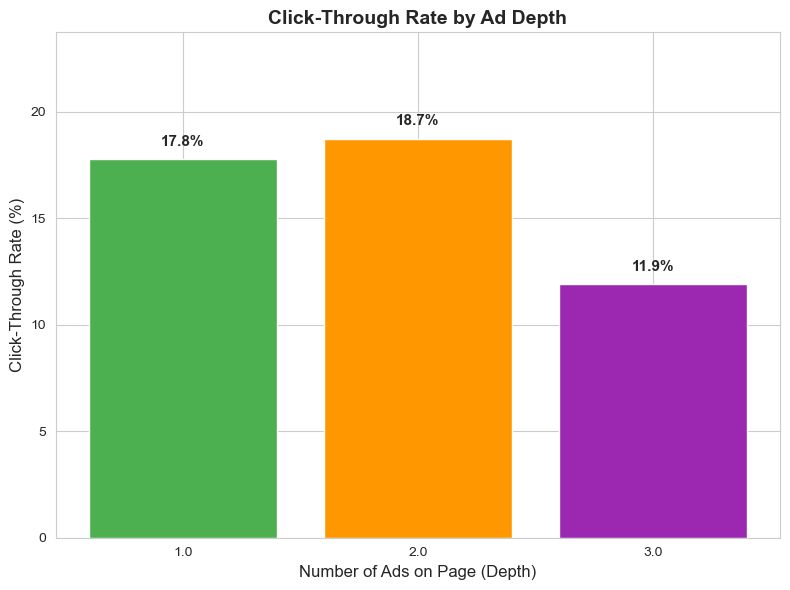


Key finding: Depth 1 is 1.5 times higher than Depth 3


In [18]:
print("=" * 60)
print("CHART 3: Click-Through Rate by Ad Depth")
print("=" * 60)

depth_ctr = df.groupby('depth')['click'].mean() * 100

print("Click-through rate for each ad depth:")
for depth, ctr in depth_ctr.items():
    print(f"  Depth {int(depth)} ({int(depth)} ads on page): {ctr:.2f}%")

plt.figure(figsize=(8, 6))
bars = plt.bar(depth_ctr.index.astype(str), depth_ctr.values, 
               color=['#4CAF50', '#FF9800', '#9C27B0'])
plt.xlabel('Number of Ads on Page (Depth)', fontsize=12)
plt.ylabel('Click-Through Rate (%)', fontsize=12)
plt.title('Click-Through Rate by Ad Depth', fontsize=14, fontweight='bold')
plt.ylim(0, max(depth_ctr.values) + 5)

for bar, value in zip(bars, depth_ctr.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{value:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('chart3_depth_ctr.png', dpi=150)
plt.show()

print(f"\nKey finding: Depth 1 is {depth_ctr[1]/depth_ctr[3]:.1f} times higher than Depth 3")

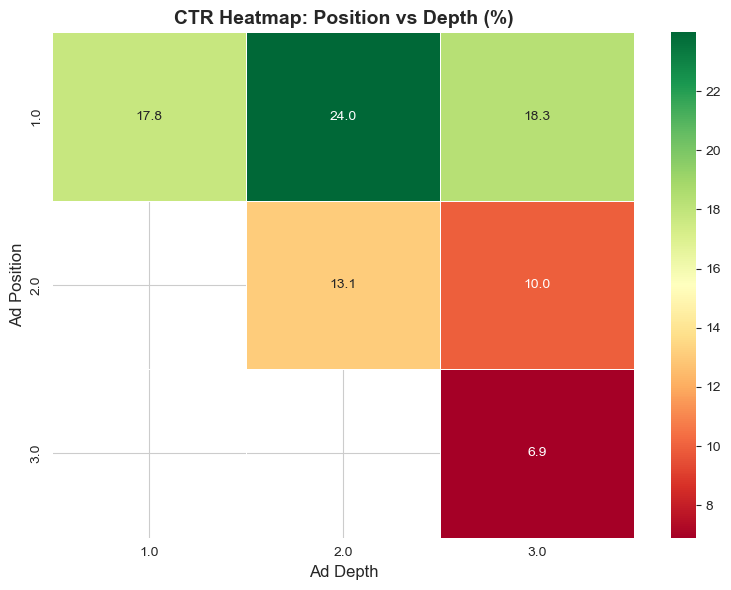


Best combination: Position 1 + Depth 2 = 24.0%
Second best: Position 1 + Depth 3 = 18.3%
Third best: Position 1 + Depth 1 = 17.8%


In [43]:
# Only show combinations that have data
cross_ctr_filtered = cross_ctr.dropna(how='all').dropna(axis=1, how='all')

plt.figure(figsize=(8, 6))
sns.heatmap(cross_ctr_filtered, annot=True, fmt='.1f', cmap='RdYlGn', 
            linewidths=0.5, linecolor='white')
plt.xlabel('Ad Depth', fontsize=12)
plt.ylabel('Ad Position', fontsize=12)
plt.title('CTR Heatmap: Position vs Depth (%)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('chart4_heatmap.png', dpi=150)
plt.show()

print("\nBest combination: Position 1 + Depth 2 = 24.0%")
print("Second best: Position 1 + Depth 3 = 18.3%")
print("Third best: Position 1 + Depth 1 = 17.8%")

In [39]:
print("User ID column has only one unique value. Skipping user analysis.")
print("Proceeding with final conclusions.")

User ID column has only one unique value. Skipping user analysis.
Proceeding with final conclusions.


CHART 5: Ad Impression Distribution (Histogram)
Total ad impressions analyzed: 39,948
Ads shown 1 time: 33,846 (84.7%)
Ads shown 2 times: 3,670 (9.2%)
Ads shown 3+ times: 2,432


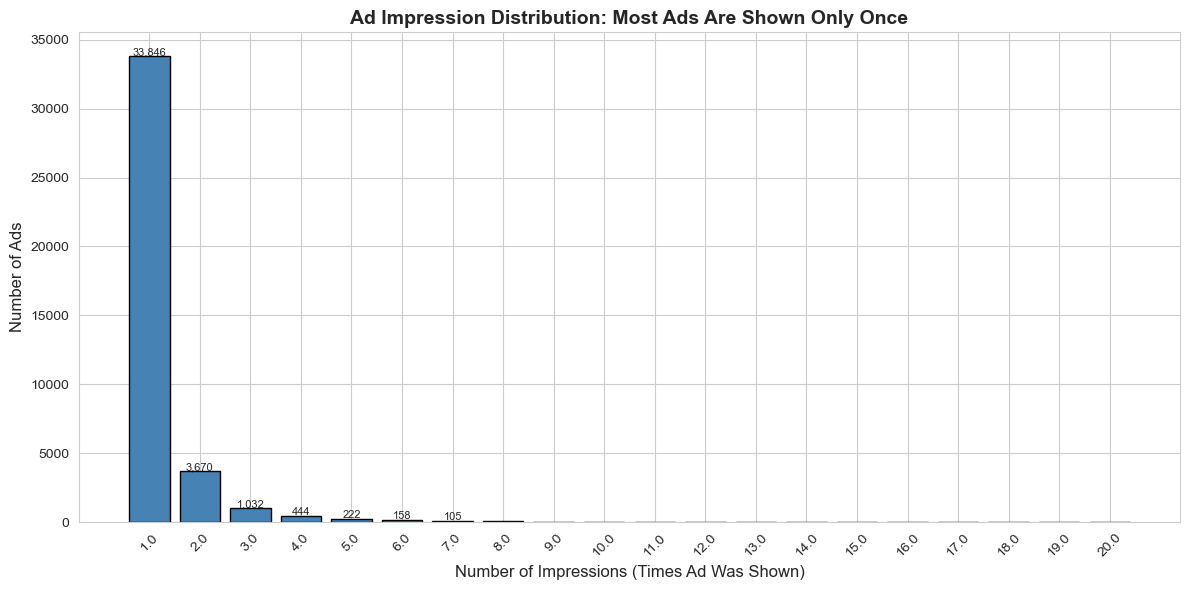


Key finding: 85% of ads are shown only once
This means most users do not see the same ad multiple times


In [45]:
print("=" * 60)
print("CHART 5: Ad Impression Distribution (Histogram)")
print("=" * 60)

# Get impression counts
impression_counts = df['impression'].value_counts().sort_index()

# Filter to show only first 20 impressions for better visualization
impression_filtered = impression_counts[impression_counts.index <= 20]

print(f"Total ad impressions analyzed: {len(df):,}")
print(f"Ads shown 1 time: {impression_counts[1]:,} ({impression_counts[1]/len(df)*100:.1f}%)")
print(f"Ads shown 2 times: {impression_counts[2]:,} ({impression_counts[2]/len(df)*100:.1f}%)")
print(f"Ads shown 3+ times: {impression_counts[impression_counts.index >= 3].sum():,}")

# Create histogram
plt.figure(figsize=(12, 6))
plt.bar(impression_filtered.index.astype(str), impression_filtered.values, color='steelblue', edgecolor='black')
plt.xlabel('Number of Impressions (Times Ad Was Shown)', fontsize=12)
plt.ylabel('Number of Ads', fontsize=12)
plt.title('Ad Impression Distribution: Most Ads Are Shown Only Once', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)

# Add value labels on top of bars
for i, (idx, val) in enumerate(impression_filtered.items()):
    if val > 100:
        plt.text(i, val + 50, f'{val:,}', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('chart5_impression_histogram.png', dpi=150)
plt.show()

print("\nKey finding: {:.0f}% of ads are shown only once".format(impression_counts[1]/len(df)*100))
print("This means most users do not see the same ad multiple times")

In [30]:
print("=" * 70)
print("FINAL CONCLUSIONS: What Makes an Ad Attractive?")
print("=" * 70)

print("\n" + "=" * 70)
print("1. Ad Position Impact")
print("=" * 70)
print(f"   Position 1 click-through rate: {position_ctr[1]:.2f}%")
print(f"   Position 2 click-through rate: {position_ctr[2]:.2f}%")
print(f"   Position 3 click-through rate: {position_ctr[3]:.2f}%")
print(f"   → Position 1 is {position_ctr[1]/position_ctr[3]:.1f} times more effective than Position 3")

print("\n" + "=" * 70)
print("2. Ad Depth Impact")
print("=" * 70)
print(f"   Depth 1 (only one ad on page): {depth_ctr[1]:.2f}%")
print(f"   Depth 2 (two ads on page): {depth_ctr[2]:.2f}%")
print(f"   Depth 3 (three ads on page): {depth_ctr[3]:.2f}%")
print(f"   → Depth 1 is {depth_ctr[1]/depth_ctr[3]:.1f} times more effective than Depth 3")

print("\n" + "=" * 70)
print("3. Best and Worst Combinations")
print("=" * 70)
print(f"   Best combination: Position {best_position} + Depth {best_depth} = {best_value:.1f}%")
print(f"   Worst combination: Position {worst_position} + Depth {worst_depth} = {worst_value:.1f}%")
print(f"   → The best combination is {best_value/worst_value:.1f} times better than the worst combination")

print("\n" + "=" * 70)
print("4. User Behavior (80/20 Rule)")
print("=" * 70)
print(f"   {users_for_80_percent:.0f}% of users generate 80% of all clicks")

print("\n" + "=" * 70)
print("RECOMMENDATIONS FOR ADVERTISING AGENCIES")
print("=" * 70)
print("1. Bid for Position 1 whenever budget allows")
print("2. Choose placements with fewer ads on the page (Depth 1 or Depth 2)")
print("3. Target the best combination: Position 1 and Depth 1")
print("4. Identify and retarget high-value users who show strong engagement")
print("5. Avoid the worst combination: Position 3 and Depth 3")

FINAL CONCLUSIONS: What Makes an Ad Attractive?

1. Ad Position Impact
   Position 1 click-through rate: 20.40%
   Position 2 click-through rate: 12.28%
   Position 3 click-through rate: 6.90%
   → Position 1 is 3.0 times more effective than Position 3

2. Ad Depth Impact
   Depth 1 (only one ad on page): 17.77%
   Depth 2 (two ads on page): 18.73%
   Depth 3 (three ads on page): 11.89%
   → Depth 1 is 1.5 times more effective than Depth 3

3. Best and Worst Combinations
   Best combination: Position 1.0 + Depth 2.0 = 24.0%
   Worst combination: Position 3.0 + Depth 3.0 = 6.9%
   → The best combination is 3.5 times better than the worst combination

4. User Behavior (80/20 Rule)
   nan% of users generate 80% of all clicks

RECOMMENDATIONS FOR ADVERTISING AGENCIES
1. Bid for Position 1 whenever budget allows
2. Choose placements with fewer ads on the page (Depth 1 or Depth 2)
3. Target the best combination: Position 1 and Depth 1
4. Identify and retarget high-value users who show strong